<div style="background-color: #c62cce ; padding: 20px; border-radius: 10px;">

<h1 style="color: black; text-align: center;">
    Projet ML : Diabetes Patient Readmission Prediction Using Machine Learning 🩺
</h1>

<h3 style="color: black; text-align: center;">
    Notebook Model training
</h3>

<h5 style="color: black; text-align: center;">
    Ovia Chanemouganandam & Sandrine Daniel – DIA 4
</h5>

</div>


Import libraries

In [53]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, classification_report
from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import BaggingClassifier, VotingClassifier, StackingClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt


## **Loading data from preprocessing**

In [ ]:

df_clean = pd.read_csv("data/df_clean.csv") 
df_scaled = pd.read_csv("data/df_scaled.csv")

X_train = pd.read_csv("data/X_train.csv")
X_test = pd.read_csv("data/X_test.csv")

y_train = pd.read_csv("data/y_train.csv")["readmitted"]
y_test = pd.read_csv("data/y_test.csv")["readmitted"]

X_train_scaled = pd.read_csv("data/X_train_scaled.csv")
X_test_scaled = pd.read_csv("data/X_test_scaled.csv")

## **Helper function for metrics**

In [ ]:
def evaluate_model_multiclass(model, X_test, y_test):
    """
    Evaluate a multiclass classifier on standard metrics.
    """
    y_pred = model.predict(X_test)

    results = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision_macro": precision_score(y_test, y_pred, average="macro"),
        "Recall_macro": recall_score(y_test, y_pred, average="macro"),
        "F1_macro": f1_score(y_test, y_pred, average="macro"),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted"),
    }

    # multiclass ROC-AUC (only if model has predict_proba)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)  # shape (n_samples, n_classes)
        results["ROC-AUC_ovr_macro"] = roc_auc_score(
            y_test, y_proba,
            multi_class="ovr",
            average="macro"
        )

    return results


# <font color='#c62cce'> <b>1. Creation of the first models  </b></font>

### **a) Logistic regression**

In [ ]:
log_reg = LogisticRegression(
    class_weight="balanced",
    multi_class="multinomial",   # tells it we have several classes
    solver="lbfgs",              # supports multinomial
    max_iter=1000
)

log_reg.fit(X_train, y_train)  # use our imputed data
results_logreg = evaluate_model_multiclass(log_reg, X_test, y_test)
results_logreg

C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linea

{'Accuracy': 0.4853908520728163,
 'Precision_macro': 0.42571152387722555,
 'Recall_macro': 0.4424425576965429,
 'F1_macro': 0.418358652451589,
 'F1_weighted': 0.4957691147460453,
 'ROC-AUC_ovr_macro': 0.6375516271808656}

## **b) Decision Tree**

In [14]:
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

results_dt = evaluate_model_multiclass(dt, X_test, y_test)
results_dt

{'Accuracy': 0.4683086023150273,
 'Precision_macro': 0.3850179075440723,
 'Recall_macro': 0.38709569292026513,
 'F1_macro': 0.38566033484406675,
 'F1_weighted': 0.4719294974637112,
 'ROC-AUC_ovr_macro': 0.5432131049283594}

## **c) RandomForestClassifier**

In [ ]:
rf = RandomForestClassifier(class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
results_rf = evaluate_model_multiclass(rf, X_test, y_test)
results_rf

{'Accuracy': 0.5750344194584672,
 'Precision_macro': 0.5427382536832507,
 'Recall_macro': 0.40119552328238245,
 'F1_macro': 0.37868265166837184,
 'F1_weighted': 0.5209425639580999,
 'ROC-AUC_ovr_macro': 0.6542720014871648}

## **d) KNeighborsClassifier**

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
results_knn = evaluate_model_multiclass(knn, X_test_scaled, y_test)
results_knn

{'Accuracy': 0.5201162612819336,
 'Precision_macro': 0.4027722406260881,
 'Recall_macro': 0.3720768595353175,
 'F1_macro': 0.3599555515777797,
 'F1_weighted': 0.48312832570326086,
 'ROC-AUC_ovr_macro': 0.5672092522145419}

## **e) XGBoost**

XGBoost doesn't support columns with names having [ or ( ...

In [17]:
X_train_xgb = X_train.rename(columns=lambda c: c.replace("[","").replace("]","").replace("(","").replace(")","").replace("<","").replace(">",""))
X_test_xgb = X_test.rename(columns=lambda c: c.replace("[","").replace("]","").replace("(","").replace(")","").replace("<","").replace(">",""))

In [ ]:
xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    eval_metric='mlogloss',
    tree_method='hist',
    random_state=42
)
xgb_base.fit(X_train_xgb, y_train)
results_xgb_base = evaluate_model_multiclass(xgb_base, X_test_xgb, y_test)
results_xgb_base

{'Accuracy': 0.5841109581357401,
 'Precision_macro': 0.5206561688030193,
 'Recall_macro': 0.4215450202477135,
 'F1_macro': 0.4102389231010712,
 'F1_weighted': 0.5432991260306119,
 'ROC-AUC_ovr_macro': 0.6776313916834861}

# <font color='#c62cce'> <b>2. Handling class imbalance </b></font>

We first handled class imbalance using class_weight = balanced now we will try SMOTE only for models that benefit from it  

In [ ]:
# We apply SMOTE only on the training set 

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("Before SMOTE:\n", y_train.value_counts())
print("\nAfter SMOTE:\n", y_train_sm.value_counts()) 

Before SMOTE:
 readmitted
0    41869
1    27719
2     8853
Name: count, dtype: int64

After SMOTE:
 readmitted
0    41869
1    41869
2    41869
Name: count, dtype: int64


## **a) Logistic Regression with SMOTE**

Here we use a pipeline: StandardScaler + LogisticRegression.

In [ ]:

# Logistic Regression with SMOTE (pipeline)


pipe_lr_smote = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        multi_class="multinomial",
        max_iter=1000,
        random_state=42
    ))
])

pipe_lr_smote.fit(X_train_sm, y_train_sm)
results_lr_smote = evaluate_model_multiclass(pipe_lr_smote, X_test, y_test)
results_lr_smote

C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


{'Accuracy': 0.5563714242007037,
 'Precision_macro': 0.4303240840480673,
 'Recall_macro': 0.384600960468334,
 'F1_macro': 0.3613791463747142,
 'F1_weighted': 0.49741322989982456,
 'ROC-AUC_ovr_macro': 0.6272699767811916}

For Logistic Regression, applying SMOTE decreased the F1-macro score.
This is expected because Logistic Regression is a linear classifier that does not model synthetic minority samples well.
SMOTE introduced interpolated points that distorted the decision boundary and degraded generalization.
Therefore, we kept the non-SMOTE version as the best-performing configuration

## **b) Decision Tree with SMOTE**

Tree models don’t need scaling, so no pipeline here

In [ ]:
# Decision Tree with SMOTE


dt_smote = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42,
    criterion="gini"  # we use gini
)

dt_smote.fit(X_train_sm, y_train_sm)

results_dt_smote = evaluate_model_multiclass(dt_smote, X_test, y_test)
results_dt_smote

{'Accuracy': 0.4507674264443425,
 'Precision_macro': 0.37066169353980793,
 'Recall_macro': 0.3722192531550718,
 'F1_macro': 0.3705729717999137,
 'F1_weighted': 0.4569586456086296,
 'ROC-AUC_ovr_macro': 0.5322497119500756}

Applying SMOTE to the Decision Tree degraded the model’s performance.
This behavior is expected because Decision Trees are very sensitive to noisy synthetic samples created by SMOTE.
Since the minority classes in this dataset are highly noisy, SMOTE amplifies this noise and leads the tree to overfit unrealistic synthetic points.
As a result, the Decision Tree without SMOTE achieves a better F1-macro score than the SMOTE version.
Therefore, for tree-based models, class_weight='balanced' (or no imbalance correction) is generally more effective than SMOTE

## **c) KNN with SMOTE + Pipeline**

For KNN we must scale, and it benefits from SMOTE, so we use an Pipeline

In [ ]:
# KNN with SMOTE + scaling 
pipe_knn_smote = ImbPipeline([
    ("smote", SMOTE(random_state=42)),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
pipe_knn_smote.fit(X_train, y_train)
results_knn_smote = evaluate_model_multiclass(pipe_knn_smote, X_test, y_test)
results_knn_smote

{'Accuracy': 0.4953342511855591,
 'Precision_macro': 0.37147617152566026,
 'Recall_macro': 0.35815345730313924,
 'F1_macro': 0.3500817324753643,
 'F1_weighted': 0.46362699156038795,
 'ROC-AUC_ovr_macro': 0.5366351432874888}

KNN performs worse when trained on SMOTE-resampled data.
This is expected because KNN is highly sensitive to the geometric structure of the data.
SMOTE generates synthetic minority-class samples by interpolating between existing points, which distorts the true distance relationships in the feature space.
As a result, the KNN decision boundaries become less meaningful, leading to lower F1-macro and ROC-AUC scores.
Therefore, the version without SMOTE provides more reliable performance for KNN on this dataset

# <font color='#c62cce'> <b>3. Stratified K-fold Cross-validation  </b></font>

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def cv_f1_macro(model, X, y, model_name="Model"):
    """
    Runs cross-validation with F1-macro and prints the mean score.
    """
    scores = cross_val_score(
        model,
        X,
        y,
        scoring="f1_macro",
        cv=cv,
        n_jobs=-1
    )
    print(f"{model_name} — CV F1-macro: {scores.mean():.4f} ± {scores.std():.4f}")
    return scores.mean()

cv_f1_macro(log_reg, X_train, y_train, "Logistic Regression (no SMOTE)")
cv_f1_macro(dt, X_train, y_train, "Decision tree (baseline)")
cv_f1_macro(xgb_base, X_train_xgb, y_train, "XGBoost (baseline)")


Logistic Regression (no SMOTE) — CV F1-macro: 0.4162 ± 0.0028
Decision tree (baseline) — CV F1-macro: 0.3850 ± 0.0049
XGBoost (baseline) — CV F1-macro: 0.4116 ± 0.0031


np.float64(0.4115964384067546)

Cross-validation scores were slightly lower than the single train/test split result, which is expected since K-fold CV provides a more robust and conservative estimate of model performance. The overall ranking of the models remained consistent

# <font color='#c62cce'> <b>4. PCA  </b></font>

## **a) Logistic Regression + PCA**

In [ ]:
# PCA + Logistic Regression

# Pipeline: Standardize -> PCA -> Logistic Regression
pipe_lr_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),  # keep 95% of the variance
    ("clf", LogisticRegression(
        class_weight="balanced",
        multi_class="multinomial",
        max_iter=1000,
        random_state=42
    ))
])

# Fit on training data (no SMOTE here)
pipe_lr_pca.fit(X_train, y_train)

# We then evaluate on test set
results_lr_pca = evaluate_model_multiclass(pipe_lr_pca, X_test, y_test)
results_lr_pca

C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


{'Accuracy': 0.4864616796695732,
 'Precision_macro': 0.4257408711834669,
 'Recall_macro': 0.44235453652233225,
 'F1_macro': 0.41706549200819126,
 'F1_weighted': 0.4944428865442535,
 'ROC-AUC_ovr_macro': 0.6350130047276116}

## **b) KNN + PCA**

In [ ]:
# PCA + KNN

# Pipeline: Standardize -> PCA -> KNN
pipe_knn_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),  # same setting for consistency
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

pipe_knn_pca.fit(X_train, y_train)
results_knn_pca = evaluate_model_multiclass(pipe_knn_pca, X_test, y_test)
results_knn_pca

{'Accuracy': 0.5121105502014176,
 'Precision_macro': 0.39712618284276485,
 'Recall_macro': 0.36184798103125226,
 'F1_macro': 0.3468352490329684,
 'F1_weighted': 0.4702342326963719,
 'ROC-AUC_ovr_macro': 0.5444847086820602}

### **PCA – Results and Interpretation**

Applying PCA before Logistic Regression and KNN does not improve performance on our
dataset. For Logistic Regression, PCA yields almost identical results to the baseline,
with a very slight decrease in F1-macro and ROC-AUC. This is expected because Logistic
Regression already handles high-dimensional sparse data reasonably well once features
are standardized.

For KNN, PCA slightly worsens performance. This is also normal: KNN relies heavily on
the original distance relationships between samples, and PCA modifies the geometry of
the feature space, which can negatively affect nearest-neighbor search.

Overall, PCA does not provide any benefit for our models and is therefore not used in
the final optimized pipeline. Tree-based models (Random Forest, XGBoost, CatBoost)
do not require PCA, and linear models show no meaningful improvement from it.

# <font color='#c62cce'> <b>5. Hyperparameters tuning  </b></font>

## Why RandomizedSearchCV instead of GridSearchCV ?

We use RandomizedSearchCV rather than GridSearchCV because our models
(Random Forest and XGBoost) have a large number of hyperparameters.
Grid Search would require evaluating hundreds or thousands of parameter
combinations, which is computationally expensive, especially with a
5-fold Stratified Cross-Validation.

Randomized Search allows us to explore a wide hyperparameter space much
faster by sampling a limited number of random combinations. In practice,
RandomizedSearchCV often reaches similar or better performance than
GridSearchCV while reducing computation time dramatically. This makes it
the most efficient and realistic choice for our project.

## **a) Logistic regression + Hyperparameters tuning**

In [ ]:
# Logistic Regression - Hyperparameter Tuning
pipe_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",
        multi_class="multinomial",
        max_iter=1000,
        random_state=42
    ))
])

param_lr = {
    "clf__C": [0.01, 0.1, 1, 10, 100],
    "clf__penalty": ["l2"],  # l1 would require saga solver
}

lr_search = RandomizedSearchCV(
    estimator=pipe_lr,
    param_distributions=param_lr,
    n_iter=5,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1,
    random_state=42,
    verbose=1
)

lr_search.fit(X_train, y_train)
best_lr = lr_search.best_estimator_
print("Best Logistic Regression params:", lr_search.best_params_)
results_lr_tuned = evaluate_model_multiclass(best_lr, X_test, y_test)
results_lr_tuned

Fitting 5 folds for each of 5 candidates, totalling 25 fits


C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in versio

Best Logistic Regression params: {'clf__penalty': 'l2', 'clf__C': 100}


{'Accuracy': 0.48625771250828614,
 'Precision_macro': 0.4267164019962813,
 'Recall_macro': 0.4433627835602843,
 'F1_macro': 0.41936969626570236,
 'F1_weighted': 0.49668483697137206,
 'ROC-AUC_ovr_macro': 0.6377958100101081}

## **b) Decision Tree + Hyperparameter Tuning**

In [ ]:
# Decision Tree - Hyperparameter Tuning

dt_base = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)
param_dt = {
    "criterion": ["gini", "entropy"],
    "max_depth": [None, 5, 10, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8]
}
dt_search = RandomizedSearchCV(
    estimator=dt_base,
    param_distributions=param_dt,
    n_iter=20,
    scoring="f1_macro",
    cv=cv,
    n_jobs=1,
    random_state=42,
    verbose=1
)
dt_search.fit(X_train, y_train)
best_dt = dt_search.best_estimator_
print("Best Decision Tree params:", dt_search.best_params_)
results_dt_tuned = evaluate_model_multiclass(best_dt, X_test, y_test)
results_dt_tuned

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Decision Tree params: {'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': 5, 'criterion': 'entropy'}


{'Accuracy': 0.4562235480087706,
 'Precision_macro': 0.42150113997873156,
 'Recall_macro': 0.44675841948296324,
 'F1_macro': 0.4015270012643218,
 'F1_weighted': 0.47153024921476605,
 'ROC-AUC_ovr_macro': 0.6390685211772376}

## **c) Random Forest + Hyperparameter Tuning**

In [ ]:
rf_base = RandomForestClassifier(
    class_weight="balanced",
    random_state=42,
    n_jobs=-1               
)
param_rf = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2, 4],
    "criterion": ["gini"],
    "max_features": ["sqrt", "log2"]
}
rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_rf,
    n_iter=15,              # less iterations
    scoring="f1_macro",
    cv=cv,                 
    n_jobs=-1,              
    random_state=42,
    verbose=1
)

rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print("Best Random Forest params:", rf_search.best_params_)
results_rf_tuned = evaluate_model_multiclass(best_rf, X_test, y_test)
results_rf_tuned




Fitting 5 folds for each of 15 candidates, totalling 75 fits
Best Random Forest params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 20, 'criterion': 'gini'}


{'Accuracy': 0.5483147213298659,
 'Precision_macro': 0.4568094456068783,
 'Recall_macro': 0.455704627278918,
 'F1_macro': 0.4559487045544746,
 'F1_weighted': 0.5457710156017308,
 'ROC-AUC_ovr_macro': 0.6664147449705436}

## **d) XGBoost + Hyperparameter Tuning**

In [ ]:
cv_xgb = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Base XGBoost model
xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    tree_method="hist",   # histogram-based is faster
    random_state=42,
    n_jobs=-1             
)

# Hyperparameter space 
param_xgb = {
    "n_estimators": [100, 200, 300],      # less than 600 → way faster
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_xgb,
    n_iter=10,              # 10 random combinations
    scoring="f1_macro",
    cv=cv_xgb,
    n_jobs=-1,       
    random_state=42,
    verbose=1
)

xgb_search.fit(X_train_xgb, y_train)
best_xgb = xgb_search.best_estimator_
print("Best XGBoost params:", xgb_search.best_params_)
results_xgb_tuned = evaluate_model_multiclass(best_xgb, X_test_xgb, y_test)
results_xgb_tuned


Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGBoost params: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 0.7}


{'Accuracy': 0.5864055887002193,
 'Precision_macro': 0.5453693713821249,
 'Recall_macro': 0.4254010626689629,
 'F1_macro': 0.41672634000514197,
 'F1_weighted': 0.5461906216977405,
 'ROC-AUC_ovr_macro': 0.6793580831176366}

# <font color='#c62cce'> <b>6. Ensemble learning  </b></font>

In [ ]:
# Ensemble 1: Bagging with Decision Tree

bagging_dt = BaggingClassifier(
    estimator=best_dt,        # or dt if you only have the baseline tree
    n_estimators=50,
    max_samples=0.8,
    max_features=1.0,
    bootstrap=True,
    n_jobs=-1,
    random_state=42
)

bagging_dt.fit(X_train, y_train)
results_bagging_dt = evaluate_model_multiclass(bagging_dt, X_test, y_test)
results_bagging_dt

{'Accuracy': 0.4843710162663811,
 'Precision_macro': 0.4271225272960526,
 'Recall_macro': 0.44787860594990664,
 'F1_macro': 0.41122497860781576,
 'F1_weighted': 0.48777696682691746,
 'ROC-AUC_ovr_macro': 0.6477156932520702}

In [ ]:
# Ensemble 2: Soft Voting (LR + RF + XGB)
voting_clf = VotingClassifier(
    estimators=[
        ("lr", best_lr),   
        ("rf", best_rf),
        ("xgb", best_xgb)
    ],
    voting="soft",
    n_jobs=-1
)

# we use the cleaned feature names version (safer for xgboost)
voting_clf.fit(X_train_xgb, y_train)
results_voting = evaluate_model_multiclass(voting_clf, X_test_xgb, y_test)
results_voting

{'Accuracy': 0.5826321962164092,
 'Precision_macro': 0.49507992120299643,
 'Recall_macro': 0.44277057958732974,
 'F1_macro': 0.44549637045687507,
 'F1_weighted': 0.557211361880272,
 'ROC-AUC_ovr_macro': 0.6757584913703688}

In [ ]:
# Ensemble 3: Stacking Classifier

stack_clf = StackingClassifier(
    estimators=[
        ("rf", best_rf),
        ("dt", best_dt),
        ("xgb", best_xgb)
    ],
    final_estimator=LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        multi_class="multinomial",
        random_state=42
    ),
    n_jobs=-1,
    passthrough=False
)

stack_clf.fit(X_train_xgb, y_train)
results_stack = evaluate_model_multiclass(stack_clf, X_test_xgb, y_test)
results_stack

C:\Users\sandr\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\linear_model\_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


{'Accuracy': 0.5080312069756769,
 'Precision_macro': 0.45201099099033226,
 'Recall_macro': 0.47233502729362903,
 'F1_macro': 0.44704523444193534,
 'F1_weighted': 0.5228382996769844,
 'ROC-AUC_ovr_macro': 0.6762667500784234}

# <font color='#c62cce'> <b>7. Advanced model  </b></font>

In [ ]:
# CatBoost (advanced model) 
cat_clf = CatBoostClassifier( 
   loss_function="MultiClass", 
   eval_metric="TotalF1", 
   iterations=500, 
   depth=6, 
   learning_rate=0.1, 
   random_seed=42, 
   verbose=False 
) 
 
cat_clf.fit(X_train, y_train) 
results_cat = evaluate_model_multiclass(cat_clf, X_test, y_test)
results_cat

{'Accuracy': 0.5885982356840549,
 'Precision_macro': 0.5614563144188837,
 'Recall_macro': 0.41882662352433075,
 'F1_macro': 0.40276682495049143,
 'F1_weighted': 0.5416977016986491,
 'ROC-AUC_ovr_macro': 0.6825328892241563}

# <font color='#c62cce'> <b>8. Confusion matrix and final comparison   </b></font>

<Figure size 600x600 with 0 Axes>

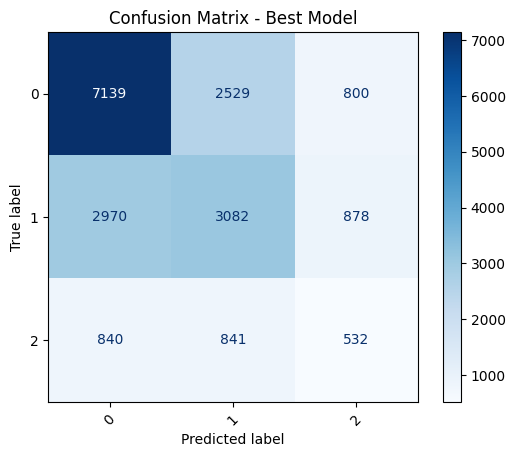

,Accuracy,Precision_macro,Recall_macro,F1_macro,F1_weighted,ROC-AUC_ovr_macro
LR_Tuned,0.486258,0.426716,0.443363,0.419370,0.496685,0.637796
DT_Baseline,0.468309,0.385018,0.387096,0.385660,0.471929,0.543213
DT_Tuned,0.456224,0.421501,0.446758,0.401527,0.471530,0.639069
RF_Tuned,0.548315,0.456809,0.455705,0.455949,0.545771,0.666415
XGB_Tuned,0.586406,0.545369,0.425401,0.416726,0.546191,0.679358
Voting,0.582632,0.495080,0.442771,0.445496,0.557211,0.675758
Stacking,0.508031,0.452011,0.472335,0.447045,0.522838,0.676267
CatBoost,0.588598,0.561456,0.418827,0.402767,0.541698,0.682533


In [ ]:
# Confusion Matrix for Best Model
best_model=best_rf   # ⚠️ use the model, not the results dict
plt.figure(figsize=(6, 6))
disp = ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues",
    xticks_rotation=45
)
plt.title("Confusion Matrix - Best Model")
plt.show()


# Final Comparison Table
# We build a dictionary only with models that exist
results_dict = {}

if 'results_lr_baseline' in globals():     results_dict["LR_Baseline"] = results_logreg
if 'results_lr_tuned' in globals():     results_dict["LR_Tuned"] = results_lr_tuned
if 'results_dt_smote' in globals():     results_dict["DT_Baseline"] = results_dt
if 'results_dt_tuned' in globals():     results_dict["DT_Tuned"] = results_dt_tuned
if 'results_rf_tuned' in globals():     results_dict["RF_Tuned"] = results_rf_tuned
if 'results_xgb_tuned' in globals():    results_dict["XGB_Tuned"] = results_xgb_tuned
if 'results_voting' in globals():       results_dict["Voting"] = results_voting
if 'results_stack' in globals():        results_dict["Stacking"] = results_stack
if 'results_cat' in globals():          results_dict["CatBoost"] = results_cat

results_summary = pd.DataFrame(results_dict).T
results_summary
  